# [Direct Preference Optimization fine tuning using LORA](https://arxiv.org/pdf/2305.18290)


DPO is an alignment technique that directly optimizes a language model using preference data (preferred vs rejected responses) without needing a separate reward model like RLHF does.


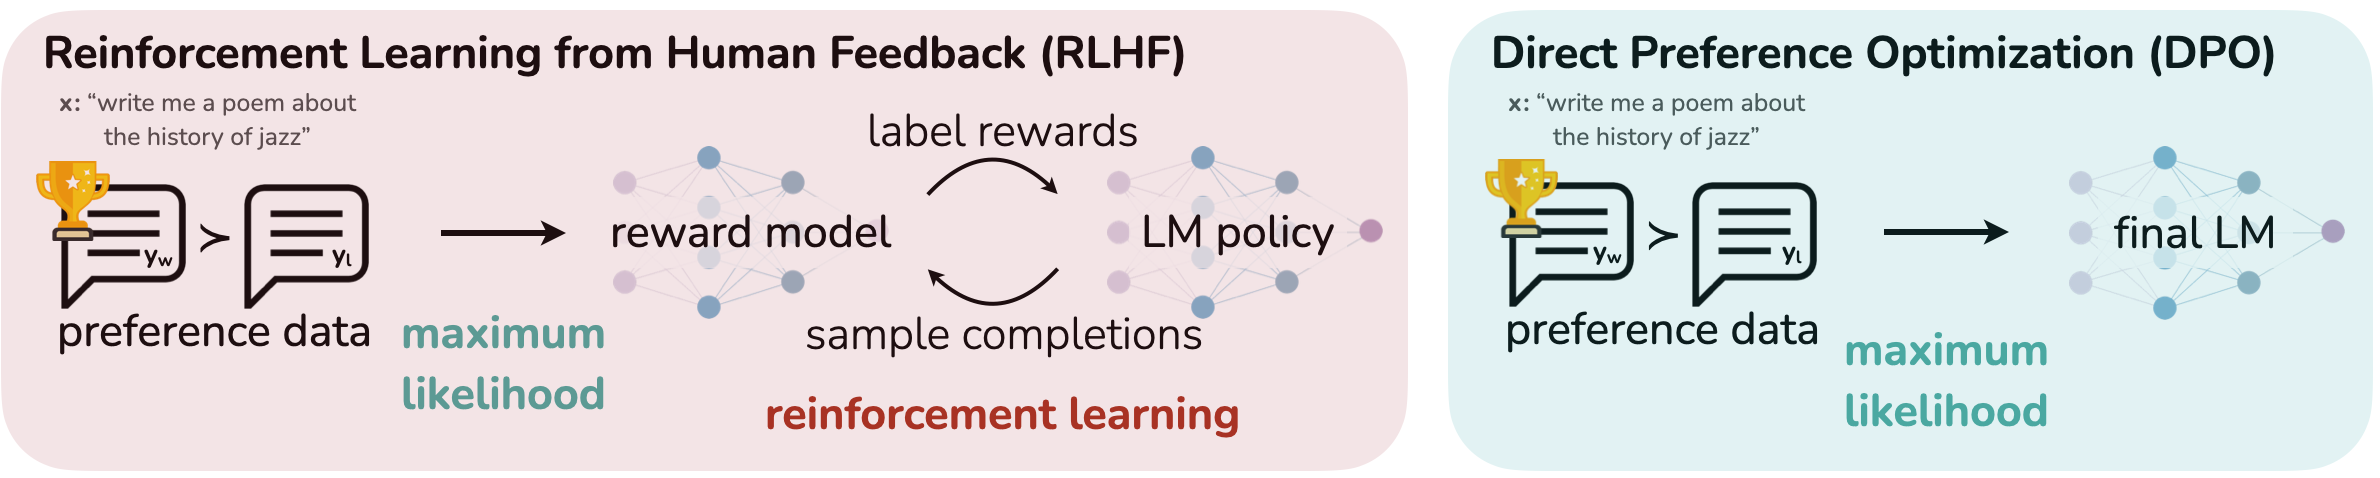

In [9]:
!pip install -q -U datasets
!pip install -q -U transformers[torch]
!pip install -q -U evaluate
!pip install -q -U peft
!pip install -q -U accelerate
!pip install -q -U torchinfo
!pip install -q -U neo4j
!pip install -q -U bitsandbytes
!pip install  -q -U trl

In [10]:
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    BitsAndBytesConfig
)
from peft import (
    prepare_model_for_kbit_training,
    get_peft_config,
    PeftModel, PeftConfig,
    get_peft_model,
    LoraConfig,
    TaskType
)

from datasets import (
    Dataset,
    load_dataset
)
from trl import DPOTrainer, DPOConfig
from torchinfo import summary
from datetime import datetime, time
from tqdm.notebook import tqdm
from neo4j import GraphDatabase
from typing import List, Dict, Any
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from sqlalchemy.exc import SQLAlchemyError
from typing import Optional, Iterable, Dict, Any, List
from neo4j import GraphDatabase
from google.colab import userdata

import pandas as pd
import re
import math, os
import textwrap
import json
import time
import torch
import evaluate
import torch
import numpy as np
import transformers
import evaluate




In [11]:

# SETUP


load_dotenv()
def get_env(key: str, default: str = None):
    """Tries os.getenv first, then Colab userdata if available."""
    return os.getenv(key) or userdata.get(key) or default

NEO4J_URI  = get_env("NEO4J_URI")   # bolt:// or neo4j://
NEO4J_USER = get_env("NEO4J_USER")
NEO4J_PASS = get_env("NEO4J_PASS")
NEO4J_DATABASE = get_env("NEO4J_DATABASE")

DB_HOST = get_env("POSTGRES_DB_HOST")
DB_PORT = int(get_env("POSTGRES_DB_PORT"))
DB_NAME = get_env("POSTGRES_DB_NAME")
DB_USER = get_env("POSTGRES_DB_USER")
DB_PASS = get_env("POSTGRES_DB_PASS")

connection_url = f"postgresql+psycopg2://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(connection_url, echo=False)
driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASS))

quantization_config = BitsAndBytesConfig(
   load_in_4bit=True,
   bnb_4bit_quant_type="nf4",
   bnb_4bit_use_double_quant=True,
   bnb_4bit_compute_dtype=torch.bfloat16
)



In [12]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')


# Define your directory
output_folder = "/content/drive/MyDrive/mids266_project/output"
data_folder = "/content/drive/MyDrive/mids266_project/data"



Mounted at /content/drive


In [13]:

smol_path = "HuggingFaceTB/SmolLM3-3B"
gemma_checkpoint = "google/gemma-2-9b-it"
model_checkpoint = smol_path


## Load  Dataset


In [14]:
v2_outputs = pd.read_sql("SELECT * FROM complete_output WHERE model_type = 'V2';", engine)

v2_outputs

,policy_id,section_id,output,prompt_text,model_type,mds,judge,total_score,source_framework,org_text,split_label
0,CL_0003-CAT-v2.0,CL_0003-CAT-v2.0:S2,"This policy applies to all personnel, consulta...",[INSTRUCTION]\nDraft the policy section titled...,V2,46.496283,99.637859,78.381229,SOC2,This policy applies to all [COMPANY_NAME] pers...,train
1,CL_0002-ISP-v1.0,CL_0002-ISP-v1.0:S3.5,"All activity on business systems, computer equ...",[INSTRUCTION]\nDraft the policy section titled...,V2,17.327435,97.831276,65.629740,SOC2,[COMPANY_NAME] shall establish coverage for al...,train
2,CL_0003-RMP-v1.1,CL_0003-RMP-v1.1:S3.2.1,"All employees, contractors, and relevant third...",[INSTRUCTION]\nDraft the policy section titled...,V2,12.784695,99.948965,65.083257,SOC2,"Risk management processes are developed, imple...",val
3,CL_0005-PVM-v2.0,CL_0005-PVM-v2.0:S3.4,Requests for exceptions to the patching proces...,[INSTRUCTION]\nDraft the policy section titled...,V2,30.357313,99.950440,72.113189,NIST CSF,Patches on production systems (e.g. servers an...,train
4,CL_0007-ACP-v1.0,CL_0007-ACP-v1.0:S3.6,Data transmitted over insecure ports and proto...,[INSTRUCTION]\nDraft the policy section titled...,V2,0.000010,70.976350,42.585814,NIST CSF,Network integrity is protected using technique...,train
...,...,...,...,...,...,...,...,...,...,...,...
1449,CL_0007-RAM-v1.0,CL_0007-RAM-v1.0:S3.5.3,"When transferring risk, a documented risk tran...",[INSTRUCTION]\nDraft the policy section titled...,V2,50.900041,99.524480,80.074704,NIST CSF,"In the event where a risk must be transferred,...",train
1450,CL_0007-RAM-v1.0,CL_0007-RAM-v1.0:S3.6,Risk assessments will be conducted on an annua...,[INSTRUCTION]\nDraft the policy section titled...,V2,23.269856,91.367652,64.128534,NIST CSF,[COMPANY_NAME] shall conduct an annual risk as...,train
1451,CL_0007-RAM-v1.0,CL_0007-RAM-v1.0:S3.7,"All employees, contractors, and relevant third...",[INSTRUCTION]\nDraft the policy section titled...,V2,34.901390,99.087436,73.413018,NIST CSF,[COMPANY_NAME] will provide training and aware...,train
1452,CL_0007-RAM-v1.0,CL_0007-RAM-v1.0:S3.8,All identified risks will be documented and pr...,[INSTRUCTION]\nDraft the policy section titled...,V2,29.432520,99.617552,71.543539,NIST CSF,If the risk rating for [COMPANY_NAME] is not a...,train


In [15]:

# load data from csv file
policy_df = pd.read_csv(f"{data_folder}/datasource.csv")

In [16]:
policy_df

,policy_id,policy_title,source_framework,policy_origin,section_id,section_title,is_heading,clause_id,clause_text,clause_full_text,clause_section_number,company_type,company_id
0,CL_0001-AUP-v2,Acceptable Use Policy,NIST CSF,client,CL_0001-AUP-v2:S1,PURPOSE,False,CL_0001-AUP-v2:1.context.523a34,The purpose of this policy is to outline the a...,The purpose of this policy is to outline the a...,1,Client,CL_0001
1,CL_0001-AUP-v2,Acceptable Use Policy,NIST CSF,client,CL_0001-AUP-v2:S2,SCOPE,False,CL_0001-AUP-v2:2.context.5af3cd,This policy applies to all City personnel and ...,This policy applies to all City personnel and ...,2,Client,CL_0001
2,CL_0001-AUP-v2,Acceptable Use Policy,NIST CSF,client,CL_0001-AUP-v2:S3.1,General Use and Ownership,False,CL_0001-AUP-v2:3.1.context.bf694e,[COMPANY_NAME] information stored on electroni...,[COMPANY_NAME] information stored on electroni...,3.1,Client,CL_0001
3,CL_0001-AUP-v2,Acceptable Use Policy,NIST CSF,client,CL_0001-AUP-v2:S3.1,General Use and Ownership,False,CL_0001-AUP-v2:3.1.context.efab41,All personnels and contractors have a responsi...,All personnels and contractors have a responsi...,3.1,Client,CL_0001
4,CL_0001-AUP-v2,Acceptable Use Policy,NIST CSF,client,CL_0001-AUP-v2:S3.1,General Use and Ownership,False,CL_0001-AUP-v2:3.1.context.5e59b4,"All personnels and contractors may access, use...","All personnels and contractors may access, use...",3.1,Client,CL_0001
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5137,CL_0007-RAM-v1.0,Risk Assessment Methodology,NIST CSF,client,CL_0007-RAM-v1.0:S3.8,Risk Treatment,False,CL_0007-RAM-v1.0:3.8.context.7b7d22,It's also required to assign a response Due Da...,It's also required to assign a response Due Da...,3.8,Client,CL_0007
5138,CL_0007-RAM-v1.0,Risk Assessment Methodology,NIST CSF,client,CL_0007-RAM-v1.0:S3.8,Risk Treatment,False,CL_0007-RAM-v1.0:3.8.context.117185,These plans are to be incorporated into Appteg...,These plans are to be incorporated into Appteg...,3.8,Client,CL_0007
5139,CL_0007-RAM-v1.0,Risk Assessment Methodology,NIST CSF,client,CL_0007-RAM-v1.0:S4,EXCEPTIONS,False,CL_0007-RAM-v1.0:4.context.b7874d,Temporary exception requests for requirements ...,Temporary exception requests for requirements ...,4,Client,CL_0007
5140,CL_0007-RAM-v1.0,Risk Assessment Methodology,NIST CSF,client,CL_0007-RAM-v1.0:S4,EXCEPTIONS,False,CL_0007-RAM-v1.0:4.context.8287d0,Need re-wording threat vectors are applicable ...,Need re-wording threat vectors are applicable ...,4,Client,CL_0007


In [17]:
# join on   policy_id between v2_outputs  the policy_df
v2_outputs = v2_outputs.merge(policy_df, left_on='policy_id', right_on='policy_id', how='left')

v2_outputs
#

,policy_id,section_id_x,output,prompt_text,model_type,mds,judge,total_score,source_framework_x,org_text,...,policy_origin,section_id_y,section_title,is_heading,clause_id,clause_text,clause_full_text,clause_section_number,company_type,company_id
0,CL_0003-CAT-v2.0,CL_0003-CAT-v2.0:S2,"This policy applies to all personnel, consulta...",[INSTRUCTION]\nDraft the policy section titled...,V2,46.496283,99.637859,78.381229,SOC2,This policy applies to all [COMPANY_NAME] pers...,...,client,CL_0003-CAT-v2.0:S1,PURPOSE,False,CL_0003-CAT-v2.0:1.context.eac4ee,[COMPANY_NAME] has developed and implemented t...,[COMPANY_NAME] has developed and implemented t...,1,Client,CL_0003
1,CL_0003-CAT-v2.0,CL_0003-CAT-v2.0:S2,"This policy applies to all personnel, consulta...",[INSTRUCTION]\nDraft the policy section titled...,V2,46.496283,99.637859,78.381229,SOC2,This policy applies to all [COMPANY_NAME] pers...,...,client,CL_0003-CAT-v2.0:S2,SCOPE,False,CL_0003-CAT-v2.0:2.context.86bf66,This policy applies to all [COMPANY_NAME] pers...,This policy applies to all [COMPANY_NAME] pers...,2,Client,CL_0003
2,CL_0003-CAT-v2.0,CL_0003-CAT-v2.0:S2,"This policy applies to all personnel, consulta...",[INSTRUCTION]\nDraft the policy section titled...,V2,46.496283,99.637859,78.381229,SOC2,This policy applies to all [COMPANY_NAME] pers...,...,client,CL_0003-CAT-v2.0:S3,POLICY REQUIREMENTS,False,CL_0003-CAT-v2.0:3.context.8a1934,Cybersecurity awareness training and education...,Cybersecurity awareness training and education...,3,Client,CL_0003
3,CL_0003-CAT-v2.0,CL_0003-CAT-v2.0:S2,"This policy applies to all personnel, consulta...",[INSTRUCTION]\nDraft the policy section titled...,V2,46.496283,99.637859,78.381229,SOC2,This policy applies to all [COMPANY_NAME] pers...,...,client,CL_0003-CAT-v2.0:S3.1,Policy and Procedures,False,CL_0003-CAT-v2.0:3.1.context.80ef83,This dedicated policy shall be maintained to s...,This dedicated policy shall be maintained to s...,3.1,Client,CL_0003
4,CL_0003-CAT-v2.0,CL_0003-CAT-v2.0:S2,"This policy applies to all personnel, consulta...",[INSTRUCTION]\nDraft the policy section titled...,V2,46.496283,99.637859,78.381229,SOC2,This policy applies to all [COMPANY_NAME] pers...,...,client,CL_0003-CAT-v2.0:S3.1,Policy and Procedures,False,CL_0003-CAT-v2.0:3.1.context.5253fe,Cybersecurity awareness training procedures sh...,Cybersecurity awareness training procedures sh...,3.1,Client,CL_0003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83441,CL_0007-RAM-v1.0,CL_0007-RAM-v1.0:S4,Temporary exceptions to this policy may be gra...,[INSTRUCTION]\nDraft the policy section titled...,V2,39.823035,99.948070,75.898056,NIST CSF,Temporary exception requests for requirements ...,...,client,CL_0007-RAM-v1.0:S3.8,Risk Treatment,False,CL_0007-RAM-v1.0:3.8.context.7b7d22,It's also required to assign a response Due Da...,It's also required to assign a response Due Da...,3.8,Client,CL_0007
83442,CL_0007-RAM-v1.0,CL_0007-RAM-v1.0:S4,Temporary exceptions to this policy may be gra...,[INSTRUCTION]\nDraft the policy section titled...,V2,39.823035,99.948070,75.898056,NIST CSF,Temporary exception requests for requirements ...,...,client,CL_0007-RAM-v1.0:S3.8,Risk Treatment,False,CL_0007-RAM-v1.0:3.8.context.117185,These plans are to be incorporated into Appteg...,These plans are to be incorporated into Appteg...,3.8,Client,CL_0007
83443,CL_0007-RAM-v1.0,CL_0007-RAM-v1.0:S4,Temporary exceptions to this policy may be gra...,[INSTRUCTION]\nDraft the policy section titled...,V2,39.823035,99.948070,75.898056,NIST CSF,Temporary exception requests for requirements ...,...,client,CL_0007-RAM-v1.0:S4,EXCEPTIONS,False,CL_0007-RAM-v1.0:4.context.b7874d,Temporary exception requests for requirements ...,Temporary exception requests for requirements ...,4,Client,CL_0007
83444,CL_0007-RAM-v1.0,CL_0007-RAM-v1.0:S4,Temporary exceptions to this policy may be gra...,[INSTRUCTION]\nDraft the policy section titled...,V2,39.823035,99.948070,75.8

In [18]:
v2_output_train_dataset = v2_outputs[v2_outputs['split_label'] == 'train'].sample(frac=0.2).reset_index(drop=True)
v2_output_val_dataset = v2_outputs[v2_outputs['split_label'] == 'val'].sample(frac=0.2).reset_index(drop=True)

In [19]:
# add a new column to v2_output_train_dataset which convertes mds score to a number between 0 and 1
min_mds = np.min(v2_output_train_dataset["mds"] )
max_mds = np.max(v2_output_train_dataset["mds"] )
v2_output_train_dataset["mds_normalized"] = (v2_output_train_dataset["mds"] - min_mds) / (max_mds - min_mds)

min_mds = np.min(v2_output_train_dataset["mds_normalized"] )
max_mds = np.max(v2_output_train_dataset["mds_normalized"] )
median_mds = np.median(v2_output_train_dataset["mds_normalized"] )
# change mds_normalized to only 4 digits after decimal
v2_output_train_dataset["mds_normalized"] = v2_output_train_dataset["mds_normalized"].round(4)
print(min_mds, max_mds, median_mds)

0.0 1.0 0.45567037141232214


In [20]:
# find max length of v2_output_train_dataset['output']

MAX_OUTPUT_LENGTH = 0
MAX_PROMPT_LENGTH = 0

for i in range(len(v2_outputs)):
  if len(v2_outputs['output'][i]) > MAX_OUTPUT_LENGTH:
    MAX_OUTPUT_LENGTH = len(v2_outputs['output'][i])
  if len(v2_outputs['prompt_text'][i]) > MAX_PROMPT_LENGTH:
    MAX_PROMPT_LENGTH = len(v2_outputs['prompt_text'][i])

print("MAX_OUTPUT_LENGTH=", MAX_OUTPUT_LENGTH)
print("MAX_PROMPT_LENGTH=", MAX_PROMPT_LENGTH)

MAX_OUTPUT_LENGTH= 1590
MAX_PROMPT_LENGTH= 15151


In [21]:
MAX_OUTPUT_LENGTH = 1600
MAX_PROMPT_LENGTH = 15250

 ### Prepare dataset for DPO
 Data Format requirements:
 pairs of responses with preferences

{
 - "prompt": "What is the capital of France?",
 - "chosen": "The capital of France is Paris.",
 - "rejected": "France's capital is London."
}

In [22]:

LOW_SCORE_THRESHOLD = 0.1   # Kept low to reduce memory requirement and increase contrast
# Select low score outputs
v2_output_low_score = v2_output_train_dataset[v2_output_train_dataset['mds_normalized'] < LOW_SCORE_THRESHOLD]
print("low score record count =", len(v2_output_low_score))

# Create DPO dataset with validation
dpo_list = []
for idx, row in v2_output_low_score.iterrows():
  if pd.notna(row["prompt_text"]) and pd.notna(row["clause_text"]) and pd.notna(row["output"]):
    dpo_list.append({
      "prompt": str(row["prompt_text"]),
      "chosen": str(row["clause_text"]),
      "rejected": str(row["output"])
    })

print(f"Valid DPO records: {len(dpo_list)}")
dpo_dataset = Dataset.from_list(dpo_list)
print(dpo_dataset)

low score record count = 1845
Valid DPO records: 1843
Dataset({
    features: ['prompt', 'chosen', 'rejected'],
    num_rows: 1843
})


In [23]:

# Split into train/test
dpo_dataset = dpo_dataset.train_test_split(test_size=0.1)

## Load Causal LLM model and Tokenizer.

`AutoModelForCausalLM` is a Generic huggingface transformers library. We freeze the model layers explicitly since the LORA adapters will be used to train smaller weight matrices

In [24]:
# Load Model and Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_checkpoint)
tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(
    model_checkpoint,
    device_map="auto",
    dtype=torch.float16,
    quantization_config=quantization_config
)

# PREPARE FOR K-BIT TRAINING
model = prepare_model_for_kbit_training(model)

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/289 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

model-00002-of-00002.safetensors:   0%|          | 0.00/1.18G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/4.97G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/182 [00:00<?, ?B/s]

## LORA setup
setup the lora config and call function to get the peft version of the model that adds the extra adapters and layers

In [25]:
# Configure LoRA
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,  # Task type
    r=16,                          # Rank of LoRA matrices (8, 16, 32, 64)
    lora_alpha=32,                 # Scaling parameter (usually 2*r)
    lora_dropout=0.05,             # Dropout probability
    target_modules=[               # Modules to apply LoRA to
        "q_proj",    # Query projection
        "k_proj",    # Key projection
        "v_proj",    # Value projection
        "o_proj",    # Output projection
        "gate_proj", # MLP gate
        "up_proj",   # MLP up
        "down_proj"  # MLP down
    ],
    bias="none",                   # Don't train bias parameters
    base_model_name_or_path=model_checkpoint # Specify the base model checkpoint
)



In [26]:
model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

# Enable gradient checkpointing and ensure input gradients are tracked
model.config.use_cache = False
model.gradient_checkpointing_enable()
model.enable_input_require_grads()

trainable params: 30,228,480 || all params: 3,105,327,104 || trainable%: 0.9734


In [27]:
_= model.to("cuda")

## Setup training arguments and train model

In [28]:
DPO_OUTPUT_DIR = f"{output_folder}/dpo-model"

#

# DPO Training Configuration
training_args = DPOConfig(
    output_dir=DPO_OUTPUT_DIR,
    num_train_epochs=2,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=2e-4,
    bf16=True,
    logging_steps=50,
    save_steps=500,
    beta=0.1,  # DPO temperature parameter
    max_length=MAX_PROMPT_LENGTH + MAX_OUTPUT_LENGTH,
    save_total_limit=3,                      # Keep only 3 checkpoints
    warmup_steps=50,                         # Warmup steps
    optim="adamw_torch",                     # Optimizer
    report_to="none",                        # Disable wandb/tensorboard
    remove_unused_columns=False,             # Keep all columns
    gradient_checkpointing=True              # Enable gradient checkpointing for memory saving
    # tokenizer=tokenizer # This argument is not accepted by DPOConfig
)

# Initialize trainer
trainer = DPOTrainer(
    model=model,
    args=training_args,
    train_dataset=dpo_dataset["train"],
    eval_dataset=dpo_dataset["test"],
    # tokenizer=tokenizer # This argument is not accepted by DPOTrainer directly in this context
)

# Train
trainer.train()
trainer.save_model(DPO_OUTPUT_DIR)

Extracting prompt in train dataset:   0%|          | 0/1658 [00:00<?, ? examples/s]

Applying chat template to train dataset:   0%|          | 0/1658 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/1658 [00:00<?, ? examples/s]

Extracting prompt in eval dataset:   0%|          | 0/185 [00:00<?, ? examples/s]

Applying chat template to eval dataset:   0%|          | 0/185 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/185 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 128012}.
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:85: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  warnings.warn(


Step,Training Loss
50,0.116400
100,0.000200
150,0.001500
200,0.005400
250,0.000000
300,0.000000
350,0.000000
400,0.000700


Step,Training Loss
50,0.116400
100,0.000200
150,0.001500
200,0.005400
250,0.000000
300,0.000000
350,0.000000
400,0.000700


In [ ]:


# Load DPO configuration
config = PeftConfig.from_pretrained(DPO_OUTPUT_DIR)

# Load base model
base_model = AutoModelForCausalLM.from_pretrained(
    config.base_model_name_or_path,
    torch_dtype=torch.float16,
    device_map="auto",
    quantization_config=quantization_config # Added quantization_config here
)

# Load LoRA adapters on top of base model
model = PeftModel.from_pretrained(base_model,DPO_OUTPUT_DIR)

# Ensure the entire model is on the CUDA device
model.to("cuda")

# Set to evaluation mode
model.eval()

# Generate text
prompt = v2_output_val_dataset.iloc[0]["prompt_text"]
inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=MAX_OUTPUT_LENGTH,  # Added to ensure total length is sufficient
        temperature=0.7,
        do_sample=True,
        top_p=0.9
    )

generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
print(generated_text)
